# Análisis Exploratorio de Datos (EDA)
## Dataset: London Indian Takeaway Orders (Kaggle)

Este notebook realiza el análisis exploratorio del dataset seleccionado 
para el TFG de predicción de demanda en restauración con reparto a domicilio.

El dataset contiene pedidos reales de dos restaurantes de comida india 
para llevar ubicados en Londres, Reino Unido.

El objetivo es entender la estructura de los datos, detectar posibles 
problemas de calidad e identificar patrones temporales que justifiquen 
el uso de variables contextuales en el modelo predictivo.

In [1]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 1. Carga de datos

Se cargan los ficheros de los dos restaurantes. 
Cada fichero contiene una línea por producto pedido, 
por lo que primero se cargan los datos 
completos y luego se agregan a nivel de pedido único.

In [2]:
# Carga de los datasets
r1 = pd.read_csv('../data/kaggle_london_indian_takeaway/restaurant-1-orders.csv')
r2 = pd.read_csv('../data/kaggle_london_indian_takeaway/restaurant-2-orders.csv')

# Convertir fechas
r1['Order Date'] = pd.to_datetime(r1['Order Date'], dayfirst=True)
r2['Order Date'] = pd.to_datetime(r2['Order Date'], dayfirst=True)

print(f"Restaurante 1: {r1.shape[0]} líneas de detalle")
print(f"Restaurante 2: {r2.shape[0]} líneas de detalle")
print(f"\nPedidos únicos R1: {r1['Order Number'].nunique()}")
print(f"Pedidos únicos R2: {r2['Order ID'].nunique()}")
print(f"\nTotal pedidos combinados: {r1['Order Number'].nunique() + r2['Order ID'].nunique()}")

Restaurante 1: 74818 líneas de detalle
Restaurante 2: 119183 líneas de detalle

Pedidos únicos R1: 13397
Pedidos únicos R2: 19658

Total pedidos combinados: 33055


### Observaciones
- El dataset contiene **33.055 pedidos reales** entre los dos restaurantes.
- Cada pedido puede contener varias líneas de detalle (productos distintos),
  lo que explica la diferencia entre líneas de detalle y pedidos únicos.
- Restaurante 1: 74.818 líneas para 13.397 pedidos (media de 5,6 productos por pedido).
- Restaurante 2: 119.183 líneas para 19.658 pedidos (media de 6,1 productos por pedido).

## 2. Estructura de los datos

In [3]:
# Primeras filas de cada restaurante
print("=== RESTAURANTE 1 ===")
print(r1.head())
print()
print("=== RESTAURANTE 2 ===")
print(r2.head())

=== RESTAURANTE 1 ===
   Order Number          Order Date            Item Name  Quantity  \
0         16118 2019-08-03 20:25:00        Plain Papadum         2   
1         16118 2019-08-03 20:25:00     King Prawn Balti         1   
2         16118 2019-08-03 20:25:00          Garlic Naan         1   
3         16118 2019-08-03 20:25:00        Mushroom Rice         1   
4         16118 2019-08-03 20:25:00  Paneer Tikka Masala         1   

   Product Price  Total products  
0           0.80               6  
1          12.95               6  
2           2.95               6  
3           3.95               6  
4           8.95               6  

=== RESTAURANTE 2 ===
   Order ID          Order Date             Item Name  Quantity  \
0     25583 2019-08-03 21:58:00  Tandoori Mixed Grill         1   
1     25583 2019-08-03 21:58:00          Madras Sauce         1   
2     25583 2019-08-03 21:58:00         Mushroom Rice         2   
3     25583 2019-08-03 21:58:00           Garlic Naan   

### Observaciones
- Ambos restaurantes tienen la misma estructura: una línea por producto 
  dentro de cada pedido.
- La columna `Order Date` contiene fecha y hora exacta de cada pedido.
- La columna `Total products` indica el número total de productos 
  en ese pedido, lo que permite identificar pedidos únicos fácilmente.
- Los productos son típicos de restaurante indio para llevar: 
  arroces, naans, currys y entrantes.

## 3. Calidad de los datos

Se analizan los valores nulos, duplicados y los tipos de datos 
para detectar problemas antes de construir el modelo.

In [4]:
print("=== RESTAURANTE 1 ===")
print("Valores nulos:")
print(r1.isnull().sum())
print(f"\nDuplicados: {r1.duplicated().sum()}")

print("\n=== RESTAURANTE 2 ===")
print("Valores nulos:")
print(r2.isnull().sum())
print(f"\nDuplicados: {r2.duplicated().sum()}")

=== RESTAURANTE 1 ===
Valores nulos:
Order Number      0
Order Date        0
Item Name         0
Quantity          0
Product Price     0
Total products    0
dtype: int64

Duplicados: 97

=== RESTAURANTE 2 ===
Valores nulos:
Order ID          0
Order Date        0
Item Name         0
Quantity          0
Product Price     0
Total products    0
dtype: int64

Duplicados: 178


### Observaciones
- **Sin valores nulos** en ninguna de las dos tablas.
- Se detectan **97 duplicados en el Restaurante 1** y **178 en el 
  Restaurante 2**, ambos representan menos del 0,2% del total de 
  registros y serán eliminados en el preprocesado.
- La calidad general de los datos es buena y permite pasar 
  directamente a la fase de análisis.

## 4. Preparación de la variable temporal

Se eliminan los duplicados y se agregan los datos a nivel de pedido 
único para construir la serie temporal de demanda diaria.

In [5]:
# Eliminar duplicados
r1_clean = r1.drop_duplicates()
r2_clean = r2.drop_duplicates()

# Agregar a nivel de pedido único
orders_r1 = r1_clean.groupby('Order Number').agg(
    datetime=('Order Date', 'first')
).reset_index()

orders_r2 = r2_clean.groupby('Order ID').agg(
    datetime=('Order Date', 'first')
).reset_index()

# Extraer variables temporales
for df in [orders_r1, orders_r2]:
    df['date'] = df['datetime'].dt.date
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.day_name()
    df['month'] = df['datetime'].dt.month

print(f"Pedidos R1 tras limpieza: {len(orders_r1)}")
print(f"Pedidos R2 tras limpieza: {len(orders_r2)}")
print(f"\nRango R1: {orders_r1['datetime'].min()} → {orders_r1['datetime'].max()}")
print(f"Rango R2: {orders_r2['datetime'].min()} → {orders_r2['datetime'].max()}")

Pedidos R1 tras limpieza: 13397
Pedidos R2 tras limpieza: 19658

Rango R1: 2015-09-01 14:42:00 → 2019-08-03 20:25:00
Rango R2: 2015-12-16 19:14:00 → 2019-08-03 21:58:00


### Observaciones
- Tras eliminar duplicados el número de pedidos no varía, lo que 
  confirma que los duplicados eran líneas de detalle repetidas, 
  no pedidos completos duplicados.
- **Restaurante 1** cubre casi **4 años** (septiembre 2015 - agosto 2019).
- **Restaurante 2** cubre casi **3,6 años** (diciembre 2015 - agosto 2019).

## 5. Análisis de patrones temporales

Para el análisis temporal se combinan los pedidos de ambos 
restaurantes en una única serie temporal.

### 5.1 Pedidos por día de la semana

C:\Users\mja\AppData\Local\Temp\ipykernel_26860\3525244620.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pedidos_dia.index, y=pedidos_dia.values, palette='Blues_d')


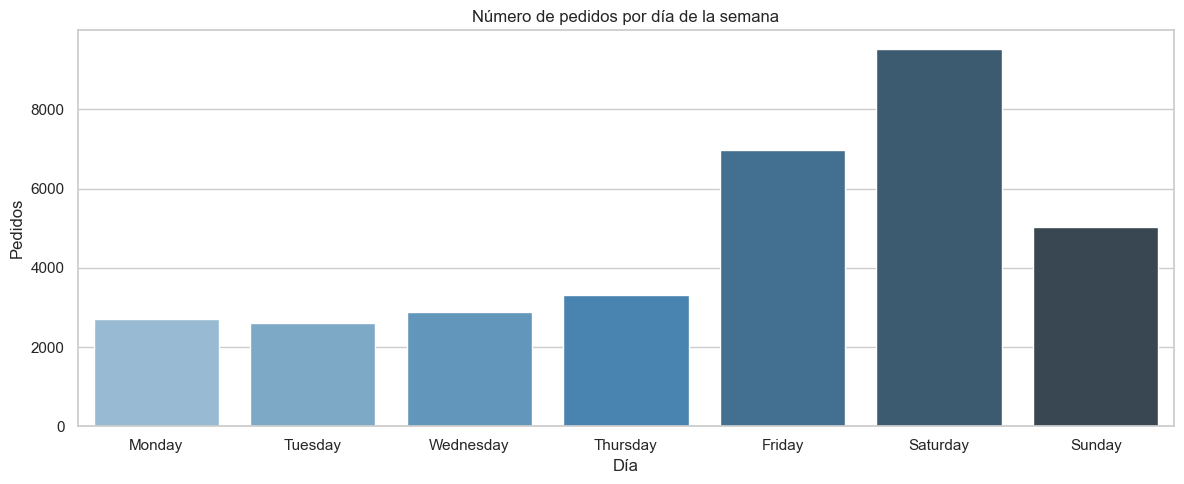

In [6]:
# Combinar los dos restaurantes
orders_total = pd.concat([
    orders_r1[['datetime', 'date', 'hour', 'day_of_week', 'month']],
    orders_r2[['datetime', 'date', 'hour', 'day_of_week', 'month']]
], ignore_index=True)

# Gráfica por día de la semana
dias_orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pedidos_dia = orders_total['day_of_week'].value_counts().reindex(dias_orden)

sns.barplot(x=pedidos_dia.index, y=pedidos_dia.values, palette='Blues_d')
plt.title('Número de pedidos por día de la semana')
plt.xlabel('Día')
plt.ylabel('Pedidos')
plt.tight_layout()
plt.savefig('../notebooks/fig_london_pedidos_dia_semana.png', dpi=150)
plt.show()

### Observaciones
- **El sábado es el día de mayor demanda** con casi 9.500 pedidos 
  acumulados, seguido del viernes con 7.000 y el domingo con 5.000.
- **Los días entre semana tienen una demanda mucho más baja y estable**, 
  en torno a 2.500-3.300 pedidos.
- El patrón es coherente con los hábitos de consumo británicos, donde 
  el takeaway es una tradición especialmente arraigada los fines de semana.
- Este patrón es claramente diferente al de una pizzería americana, 
  lo que refuerza la importancia de la variable día de la semana 
  como predictor clave en el modelo.

### 5.2 Pedidos por franja horaria

C:\Users\mja\AppData\Local\Temp\ipykernel_26860\798259964.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pedidos_hora.index, y=pedidos_hora.values, palette='Blues_d')


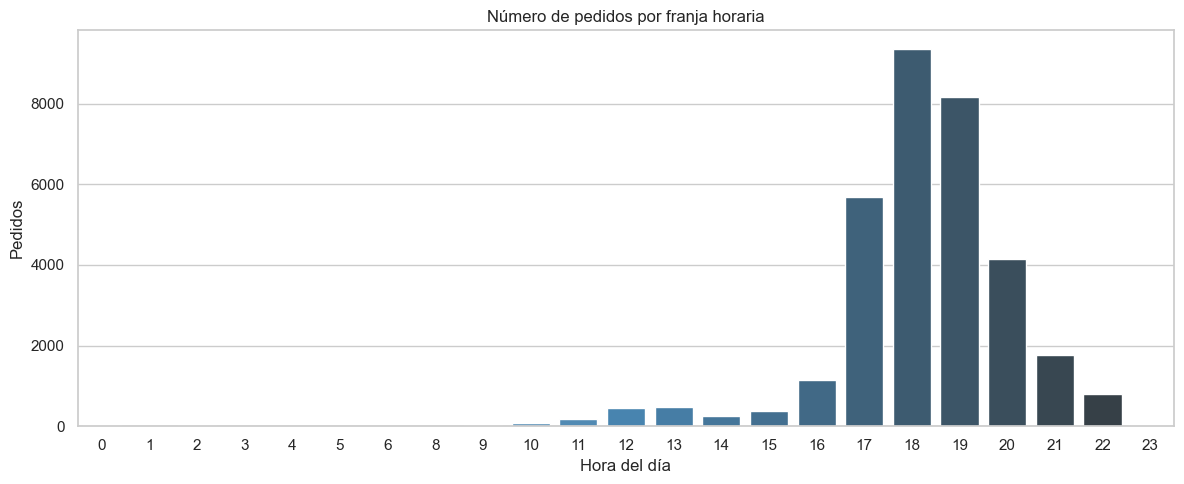

In [7]:
pedidos_hora = orders_total['hour'].value_counts().sort_index()

sns.barplot(x=pedidos_hora.index, y=pedidos_hora.values, palette='Blues_d')
plt.title('Número de pedidos por franja horaria')
plt.xlabel('Hora del día')
plt.ylabel('Pedidos')
plt.tight_layout()
plt.savefig('../notebooks/fig_london_pedidos_hora.png', dpi=150)
plt.show()

### Observaciones
- Se identifica **un único pico de demanda claro entre las 17h y las 20h**,
  con el máximo a las 18h con casi 9.500 pedidos acumulados.
- A diferencia de la pizzería americana, **no hay pico de mediodía**,
  lo que es coherente con los hábitos británicos donde el takeaway 
  se asocia principalmente a la cena.
- El local opera principalmente entre las 16h y las 22h, con actividad 
  residual en horas de almuerzo.
- La franja horaria es una variable contextual clave para el modelo,
  con una concentración de demanda muy marcada en las horas de cena.

### 5.3 Pedidos por mes

C:\Users\mja\AppData\Local\Temp\ipykernel_26860\1447626679.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=meses, y=pedidos_mes.values, palette='Blues_d')


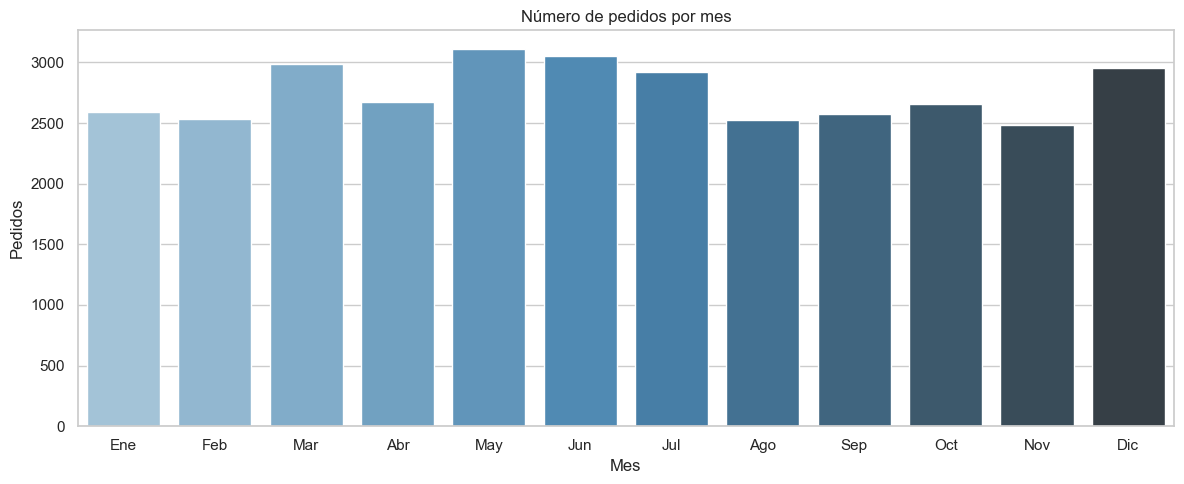

In [9]:
meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']

pedidos_mes = orders_total['month'].value_counts().sort_index()

sns.barplot(x=meses, y=pedidos_mes.values, palette='Blues_d')
plt.title('Número de pedidos por mes')
plt.xlabel('Mes')
plt.ylabel('Pedidos')
plt.tight_layout()
plt.savefig('../notebooks/fig_london_pedidos_mes.png', dpi=150)
plt.show()

### Observaciones
- La demanda mensual es **muy estable** a lo largo del año, con una 
  variación máxima del 20% entre el mes más alto y el más bajo.
- **Mayo y junio son los meses de mayor demanda**, con más de 3.000 
  pedidos mensuales acumulados.
- **Noviembre es el mes más bajo**, con aproximadamente 2.500 pedidos.
- La estabilidad mensual es coherente con Londres, donde el takeaway 
  es un hábito de consumo constante independientemente de la estación.
- Este patrón refuerza la necesidad de incorporar variables contextuales 
  externas como el clima o los festivos para explicar las variaciones 
  puntuales que los patrones temporales por sí solos no capturan.

## 6. Serie temporal diaria

Se analiza la evolución del número de pedidos día a día a lo largo 
de todo el periodo. Esta es la variable objetivo que utilizará el 
modelo Prophet para realizar las predicciones.

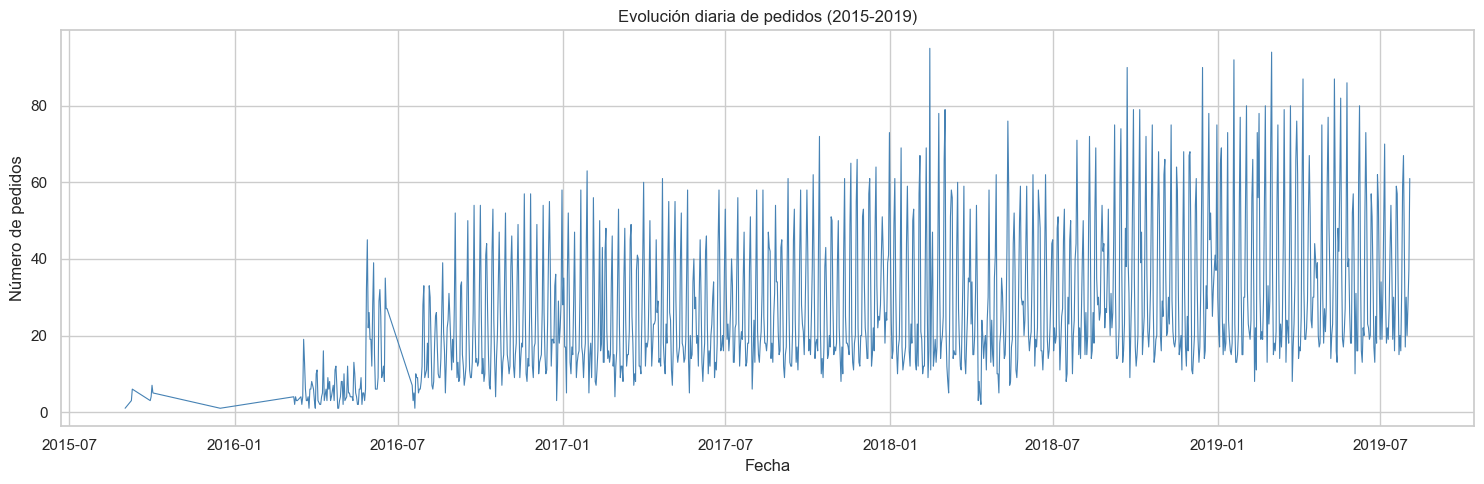

Media diaria de pedidos: 27.2
Máximo diario: 95 pedidos
Mínimo diario: 1 pedidos


In [10]:
import pandas as pd

# Convertir date a datetime
orders_total['date'] = pd.to_datetime(orders_total['date'])

# Agrupar pedidos por día
pedidos_diarios = orders_total.groupby('date').size().reset_index(name='num_pedidos')

# Visualizar la serie temporal
plt.figure(figsize=(15, 5))
plt.plot(pedidos_diarios['date'], pedidos_diarios['num_pedidos'],
         color='steelblue', linewidth=0.8)
plt.title('Evolución diaria de pedidos (2015-2019)')
plt.xlabel('Fecha')
plt.ylabel('Número de pedidos')
plt.tight_layout()
plt.savefig('../notebooks/fig_london_serie_temporal_diaria.png', dpi=150)
plt.show()

print(f"Media diaria de pedidos: {pedidos_diarios['num_pedidos'].mean():.1f}")
print(f"Máximo diario: {pedidos_diarios['num_pedidos'].max()} pedidos")
print(f"Mínimo diario: {pedidos_diarios['num_pedidos'].min()} pedidos")

### Observaciones
- La serie muestra una **tendencia ascendente clara** a lo largo de 
  los 4 años, lo que indica que el negocio fue creciendo 
  progresivamente desde su apertura.
- Los primeros meses de 2015-2016 muestran muy pocos pedidos diarios, 
  coherente con un negocio en fase de arranque.
- A partir de 2017 la serie se estabiliza con una media de pedidos 
  diarios mucho más alta y patrones semanales claramente visibles.
- Se aprecian **caídas puntuales a cero o casi cero** que probablemente 
  corresponden a días de cierre del local o festivos.
- Esta serie temporal constituye la variable objetivo `y` que 
  utilizará Prophet para entrenar el modelo predictivo.